In [7]:
# Welcome to your new notebook
# Type here in the cell editor to add code!


StatementMeta(, c8a277f9-5713-4df2-9fd5-4488214168d6, 9, Finished, Available, Finished, False)

In [4]:
df = spark.read.option("multiline", "true").json("Files/bing_latest_news.json")
# df now is a Spark DataFrame containing JSON data from "Files/bing_latest_news.json".
display(df)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 6, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, f25391eb-be68-4b0b-8044-9e9b50d4c928)

In [5]:
df=df.select('organic_results')

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 7, Finished, Available, Finished, False)

In [6]:
display(df)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 8, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, f6d1aa27-c338-40c9-bb1b-9da20e4a0756)

In [7]:
from pyspark.sql.functions import explode
df_exploded=df.select(explode(df["organic_results"]).alias("json_object"))

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 9, Finished, Available, Finished, False)

In [8]:
display(df_exploded)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 10, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, becc9f1f-40b9-42f0-a4b2-c2087bf008a3)

In [9]:
# this will have all the info about the news in json string format
json_list=df_exploded.toJSON().collect()

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 11, Finished, Available, Finished, False)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 12, Finished, Available, Finished, False)

['{"json_object":{"date":"18h","favicon":"","link":"https://www.usnews.com/news/us/articles/2026-03-05/the-latest-new-iranian-attacks-target-israel-and-us-bases-as-more-israeli-strikes-hit-lebanon","position":1,"snippet":"House lawmakers on Thursday rejected a war powers resolution to halt Trump’s attack on Iran, a day after the Senate voted ...","source":"U.S. News & World Report","thumbnail":"","title":"The Latest: House Joins Senate in Rejecting War Powers Resolution to Halt US Attacks on Iran"}}', '{"json_object":{"date":"1d","favicon":"","link":"https://www.usnews.com/news/politics/articles/2026-03-05/the-latest-trump-fires-homeland-security-secretary-noem-amid-criticism-over-immigration-enforcement","position":2,"snippet":"President Donald Trump has fired his embattled Homeland Security Secretary Kristi Noem and says he’ll nominate in her place ...","source":"U.S. News & World Report","thumbnail":"","title":"The Latest: Trump Fires Homeland Security Secretary Noem Amid Criticism 
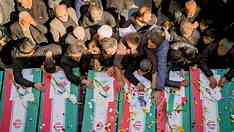
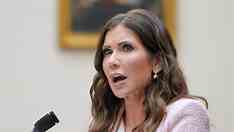
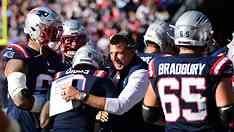

In [10]:
print(json_list)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 13, Finished, Available, Finished, False)

{"json_object":{"date":"18h","favicon":"","link":"https://www.usnews.com/news/us/articles/2026-03-05/the-latest-new-iranian-attacks-target-israel-and-us-bases-as-more-israeli-strikes-hit-lebanon","position":1,"snippet":"House lawmakers on Thursday rejected a war powers resolution to halt Trump’s attack on Iran, a day after the Senate voted ...","source":"U.S. News & World Report","thumbnail":"","title":"The Latest: House Joins Senate in Rejecting War Powers Resolution to Halt US Attacks on Iran"}}

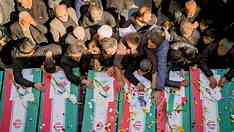

In [11]:
print(json_list[0])

In [12]:
#converting list to dictionary using json.loads()

import json

news_json=json.loads(json_list[4])

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 14, Finished, Available, Finished, False)

In [13]:
display(type(news_json))

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 15, Finished, Available, Finished, False)

dict

In [14]:
print(news_json)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 16, Finished, Available, Finished, False)

{'json_object': {'date': '2d', 'favicon': '', 'link': 'https://www.reuters.com/technology/openai/', 'position': 5, 'snippet': 'Reuters.com is your online source for the latest news stories and current events, ensuring our readers up to date with any breaking news developments ...', 'source': 'Reuters', 'title': "OpenAI News | Today's Latest Stories | Reuters"}}


In [15]:
print(news_json['json_object']['snippet'])

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 17, Finished, Available, Finished, False)

Reuters.com is your online source for the latest news stories and current events, ensuring our readers up to date with any breaking news developments ...


In [16]:
#date favicon link position snippet source title
print(news_json['json_object']['date'])
print(news_json['json_object']['favicon'])
print(news_json['json_object']['link'])
print(news_json['json_object']['position'])
print(news_json['json_object']['snippet'])
print(news_json['json_object']['source'])
print(news_json['json_object']['title'])

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 18, Finished, Available, Finished, False)

2d

https://www.reuters.com/technology/openai/
5
Reuters.com is your online source for the latest news stories and current events, ensuring our readers up to date with any breaking news developments ...
Reuters
OpenAI News | Today's Latest Stories | Reuters


In [17]:
title=[]
snippet=[]
date=[]
link=[]
favicon=[]
source=[]
position=[]

for json_str in json_list:
    try:
        article=json.loads(json_str)

        title.append(article['json_object']['title'])
        snippet.append(article['json_object']['snippet'])
        date.append(article['json_object']['date'])
        link.append(article['json_object']['link'])
        favicon.append(article['json_object']['favicon'])
        source.append(article['json_object']['source'])
        position.append(article['json_object']['position'])

    except Exception as e:
        print(f"Error processing JSON Object:{e}")

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 19, Finished, Available, Finished, False)

In [18]:
date

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 20, Finished, Available, Finished, False)

['18h', '1d', '1d', '5y', '2d']

In [19]:
from pyspark.sql.types import StructType, StructField, StringType

#combine lists
data=list(zip(title,snippet,position,date,favicon,source,link))

schema=StructType([
    StructField("title",StringType(),True),
    StructField("snippet",StringType(),True),
    StructField("position",StringType(),True),
    StructField("date",StringType(),True),
    StructField("favicon",StringType(),True),
    StructField("source",StringType(),True),
    StructField("link",StringType(),True)
])

df_cleaned=spark.createDataFrame(data,schema=schema)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 21, Finished, Available, Finished, False)

In [20]:
display(df_cleaned)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 22, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 55b334de-c4f5-4a91-8eb2-62a092cef1a7)

In [21]:
from pyspark.sql.functions import to_date, date_format

df_cleaned_final=df_cleaned.withColumn("date",date_format(to_date("date"),"dd-MM-yyyy"))

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 23, Finished, Available, Finished, False)

In [22]:
display(df_cleaned)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 24, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, d8799c67-bf69-4faa-8305-d7678937c4e2)

In [23]:
#df_cleaned.write.format("delta").saveAsTable("tbl_latest_news")

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 25, Finished, Available, Finished, False)

In [1]:
#we cant use overwrite method as when next day news will come old data gets vanished

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 3, Finished, Available, Finished, False)

In [2]:
#using .mode("append")
#same data also gets appended duplication

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 4, Finished, Available, Finished, False)

### Incremental Load

### Two Ways-> Type1 and Type 2

In [26]:
#using type 1
from pyspark.sql.utils import AnalysisException

try:
    table_name = "tbl_latest_news"

    df_cleaned.write.format("delta").saveAsTable(table_name)

except AnalysisException:
    print("Table already exists")

    df_cleaned.createOrReplaceTempView("vw_df_cleaned")

    spark.sql(f"""
        MERGE INTO {table_name} target_table
        USING vw_df_cleaned source_view
        ON source_view.link = target_table.link

        WHEN MATCHED AND (
            source_view.title <> target_table.title OR
            source_view.snippet <> target_table.snippet OR
            source_view.date <> target_table.date OR
            source_view.favicon <> target_table.favicon OR
            source_view.source <> target_table.source OR
            source_view.position <> target_table.position
        )
        THEN UPDATE SET *

        WHEN NOT MATCHED THEN
        INSERT *
    """)

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 28, Finished, Available, Finished, False)

Table already exists


In [29]:
%%sql
select count(*) from tbl_latest_news

StatementMeta(, f99b80e3-17e6-4d73-b11c-8d453b2e2603, 31, Finished, Available, Finished, False)

<Spark SQL result set with 1 rows and 1 fields>